# Сервис такси «Карету мне» 

## Проверка продуктовой гипотезы с помощью А/В/С эксперимента  

### Цель исследования

В приложении вызова такси исследование показало, что пассажиры чаще отменяют заказы, если предварительное время ожидания машины не совпадает с реальным. Пользователи видят, что такси не успевает к обещанному времени, и отменяют заказы. Если предварительное и реальное время ожидания значительно различаются, пользователь может отменить заказ сразу.

Для решения проблемы в компании разработали **новую математическую модель**, которая должна более точно прогнозировать время ожидания.

Гипотеза продуктовой команды звучит так: «Более точный прогноз времени ожидания повысит качество пользовательского опыта. Это, в свою очередь, увеличит вероятность того, что заказ завершится поездкой».

Сейчас **модель реализована в двух вариантах**, которые имеют небольшие различия. Аналитику нужно проверить гипотезу с помощью **A/B/C-эксперимента** и проанализировать результаты. 

### Задачи

- Определить и рассчитать параметры теста.
- Оценить корректность проведения теста.
- Проанализировать результаты теста.

Описание данных

- users — таблица с метаданными зарегистрированных пользователей приложения за период с 2024-01-01 по 2024-10-27;
- events — таблица с пользовательскими событиями в приложении за период с 2024-09-23 по 2024-10-27;
- orders — таблица с метаданными о поездках пользователей за период с 2024-09-23 по 2024-10-27.

Таблица users:

- user_id — уникальный идентификатор пользователя;
- registration_date — дата регистрации в сервисе;
- country_code — код страны пользователя (RU, BY, KZ, UZ);
- traffic_type — источник привлечения пользователя в сервис (organic, paid, referral);
- platform — платформа пользователя (android, ios).

Таблица events:

- user_id — уникальный идентификатор пользователя;
- time — время события;
- session_id — идентификатор сессии;
- event_name — название события;
- app_start — запуск приложения;
- registration_complete — прохождение регистрации;
- order_initiate — открытие экрана заказа;
- order_create — создание заказа;
- order_cancel — отмена заказа;
- order_rate — выставление оценки заказу.

Таблица orders:

- user_id — уникальный идентификатор пользователя;
- order_id — уникальный идентификатор заказа;
- order_time — время создания заказа;
- ride_start_time — время старта поездки;
- ride_finish_time — время завершения поездки;
- status — статус заказа (completed, cancelled_order_by_client, cancelled_order_by_driver);
- paid_amt — стоимость заказа;
- payment_type — тип оплаты (cash, card, na).

После запуска теста стали доступны данные о сплите пользователей. Эти данные находятся в таблице split_data. Список столбцов:
user_id — уникальный идентификатор пользователя;
time — время попадания пользователя в экспериментальную группу;
group_name — название экспериментальной группы.

### План работы

1. Составить карту эксперимента:
  - выбрать ключевую и дополнительные метрики.
  - определить сегмент аудитории, которая будет участвовать в эксперименте.
  - определить ограничение по MDE ключевой метрики.
  - определить дополнительные условия проведения теста.


2. Оценить корректность проведения теста
  - Проверить правильность сплитования пользователей
  - Рассчитать метрики в динамике


3.  Подвести итоги теста:
  - Рассчитать метрики
  - Оценить статистическую занчимость теста
    
4. Сформулировать выводы

## Загрузка библиотек

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
## Диаграммы Венна
from matplotlib_venn import venn3

In [4]:
from scipy.stats import t, ttest_ind

In [5]:
# Настройки отображения DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

In [6]:
# Уменьшение разрешения DPI для графиков 
plt.rcParams['figure.dpi'] = 72

## Загрузка и предобработка данных

In [7]:
# Загружаем данные - Заказы
try:  
    orders = pd.read_csv('datasets/PA_5_10_1_orders.csv')
    display(f'Файл успешно загружен') 
except:
    # ошибка
    display(f'Ошибка при загрузке файла')     

'Файл успешно загружен'

In [8]:
orders.head()

,index,user_id,order_id,order_time,ride_start_time,ride_finish_time,status,paid_amt,payment_type
0,14,00019148-3158-4ebe-aae0-25cd0e1b1b8a,a4e8f585-6963-4de7-9c0d-85631cd0aec3,2024-10-23 02:58:57,2024-10-23 03:05:47.240,2024-10-23 03:41:41,completed,1025,card
1,15,00019148-3158-4ebe-aae0-25cd0e1b1b8a,a42ca294-1daf-4abb-8781-16c957cb7336,2024-10-23 07:54:28,2024-10-23 07:59:55.960,2024-10-23 08:24:50,completed,364,card
2,16,00019148-3158-4ebe-aae0-25cd0e1b1b8a,a6d71fde-efb8-4087-ba44-1a6c0b164337,2024-10-27 12:03:40,2024-10-27 12:09:47.400,2024-10-27 12:31:30,completed,640,card
3,36,00047b5c-e935-4b2f-affb-138f33bf46d0,6abcadf0-33c8-4da2-ab87-c5ad091d6190,2024-10-01 01:47:12,2024-10-01 01:51:56.130,2024-10-01 02:30:15,completed,688,card
4,73,000cad75-a374-4043-b40b-0d66519679ec,47c84612-2197-4ad5-869b-f2843fb69981,2024-09-30 05:29:22,2024-09-30 05:34:17.680,2024-09-30 05:52:50,completed,328,card


In [9]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35085 entries, 0 to 35084
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   index             35085 non-null  int64 
 1   user_id           35085 non-null  object
 2   order_id          35085 non-null  object
 3   order_time        35085 non-null  object
 4   ride_start_time   30734 non-null  object
 5   ride_finish_time  30734 non-null  object
 6   status            35085 non-null  object
 7   paid_amt          35085 non-null  int64 
 8   payment_type      35085 non-null  object
dtypes: int64(2), object(7)
memory usage: 2.4+ MB


In [10]:
# преобразуем столбец в дату
orders['order_time'] = pd.to_datetime(orders['order_time'])

In [11]:
# Загружаем данные - события
try:
#пробуем  
    events = pd.read_csv('datasets/PA_5_10_1_events.csv')
    display(f'Файл успешно загружен') 
except:
    # ошибка
    display(f'Ошибка при загрузке файла')     

'Файл успешно загружен'

In [12]:
events.head()

,index,user_id,time,session_id,event_name
0,269229,ad982279-4c75-400a-a532-4b0cc5a87487,2024-09-23 00:01:03,948237,app_start
1,269230,ad982279-4c75-400a-a532-4b0cc5a87487,2024-09-23 00:01:08,948237,order_initiate
2,269231,ad982279-4c75-400a-a532-4b0cc5a87487,2024-09-23 00:01:22,948237,order_create
3,144284,8aebd6dd-3f24-4eb0-a330-0f4a9a375135,2024-09-23 00:01:50,901120,app_start
4,144285,8aebd6dd-3f24-4eb0-a330-0f4a9a375135,2024-09-23 00:01:52,901120,order_initiate


In [13]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158233 entries, 0 to 158232
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   index       158233 non-null  int64 
 1   user_id     158233 non-null  object
 2   time        158233 non-null  object
 3   session_id  158233 non-null  int64 
 4   event_name  158233 non-null  object
dtypes: int64(2), object(3)
memory usage: 6.0+ MB


In [14]:
# преобразуем столбец в дату
events['time'] = pd.to_datetime(events['time'])

## Расчет параметров теста

### Выбор метрик

**Ключевая метрика** - конверсия из создания заказа в успешную поездку - **C2R** (Conversion to Ride).
Это **ratio-метрика** (показатель отношения).

C2R = (Успешные поездки/Созданные заказы) * 100%

**Барьерная метрика** - выручка на пользователя, т.к. не нужно чтобы новая модель снижала пользовательские и метирики и активность заказов.

**Вспомогательные метрики**, которые помогут отследить эффект:
- Конверсия из просмотра формы заказа в заказ (CR),
- Количество поездок на пользователя.

Дполнительные условия, котовые нужно учесть в этом тесте:

- Нужна поправка на множественное тестирование, так как это A/B/C-тест - у нас 2 вариант новой модели.
- Нужно применить линеаризацию, так как ключевая метрика — это метрика отношения.

### Условия проведения теста

**Задание:**

- MDE. 
С высокой вероятностью отслеживать изменения ключевой метрики на 4% и более. Относительный MDE зафиксирован на этом уровне.

- Длительность. На проведение теста выделено две недели — с 14.10.2024 до 27.10.2024.

- Аудитория. Тестирование идет на всех пользователях, которые будут заходить в приложение, независимо от сегмента. 
При этом запланированы другие тесты — забирать всю аудиторию не совсем правильно. 
Необходимо определить оптимальный размер трафика для теста с учётом временных ограничений и MDE.
    
- Аудитория. Равномерный сплит пользователей по группам: 33%, 33% и 33%.

- Мощность теста. Необходимо выдержать мощность на уровне 0.8.

- Поправка на множественные гипотезы. **В тесте три гипотезы**, поэтому будем использовать поправку Бонферрони.

### Дизайн эксперимента

По продуктовой гипотезе формулируем нулевую и альтернативную гипотезы для ключевой метрики в эксперименте:

**Нулевая гипотеза:** Средние значения ключевой метрики у групп А и B в генеральной совокупности равны.

**Альтернативная гипотеза:** Средние значения ключевой метрики у групп А и B в генеральной совокупности не равны.

При проведении теста будем исходить из таких предположений:
- Поведение каждого пользователя не зависит от поведения других пользователей, то есть каждый пользователь является независимым наблюдением.
- При достаточно большом количестве наблюдений распределение средних значений выборок ключевой метрики стремится к нормальному согласно центральной предельной теореме.

Дополняем параметры теста:

-  Исходя из ключевой метрики и гипотез выбираем подходящий статистический критерий - T-test Стьюдента с линеаризацией
(Ключевая метрика относится к ratio-метрикам. Будем сравнивать её средние значения между группами.)

#### Расчет MDE

**Задание**. Нужно рассчитать MDE ключевой метрики на разных уровнях пользовательского трафика. Условие, которое нужно учесть: относительный MDE — не выше 4%.

Предэкспериментального период: с 2024-09-23 по 2024-10-06.
На успешное завершение поездки указывает статус *completed*. 

Найти и запомнить минимальную долю трафика, при которой MDE будет держаться на требуемом уровне. 

Ключевая метрика — конверсия из создания заказа в успешную поездку (C2R).

Формула расчёта: количество поездок, которые завершились успешно / общее количество созданных заказов. 

In [15]:
# Параметры для расчёта 
alpha = 0.05 # уровень значимости
beta = 0.2 # вероятность ошибки II рода
group_count = 3 # количество групп

In [16]:
rollout_share = 50  # % трафика на эксперимент (меняем значение и смотрим на результат MDE)

In [17]:
# Зададим названия столбцов для числителя и знаменателя
unit_name = 'user_id'
numerator = 'completed_orders'
denominator = 'total_orders'

# Предпериод
start_date = pd.Timestamp('2024-09-23 00:00:00')
end_date = pd.Timestamp('2024-10-06 23:59:59')

# Фильтрация и агрегация данных
data_exp_orders = orders[
   (orders['order_time'] >= start_date) &
   (orders['order_time'] <= end_date) &
   (orders['status'] != 'cancelled_order_by_driver')]
completed_orders = data_exp_orders[data_exp_orders['status'] == 'completed'].groupby('user_id')[
   'order_id'].nunique().reset_index()
completed_orders = completed_orders.rename(columns={'order_id': 'completed_orders'})
total_orders = data_exp_orders.groupby('user_id')['order_id'].nunique().reset_index()
total_orders = total_orders.rename(columns={'order_id': 'total_orders'})
df_merged = pd.merge(completed_orders, total_orders, how='outer', on='user_id')
df_merged.fillna(0, inplace=True)

# Расчёт глобального значения метрики
global_ratio = df_merged[numerator].sum() / df_merged[denominator].sum()

# Линеаризация
df_merged['linearized_metric'] = df_merged[numerator] - global_ratio * df_merged[denominator]

Итак, мы превратили метрику (дробь) в линейную по формуле:

L = Количество успешных поездок - Глобальная метрика * Количество поездок всего

In [18]:
df_merged.head()

,user_id,completed_orders,total_orders,linearized_metric
0,00047b5c-e935-4b2f-affb-138f33bf46d0,1.0,1,0.126186
1,000cad75-a374-4043-b40b-0d66519679ec,1.0,1,0.126186
2,001c57aa-e1f1-40bf-9d79-8e064ee03891,1.0,1,0.126186
3,0020b2b6-38f5-4031-9cc1-41b38f5beb75,0.0,1,-0.873814
4,0031962e-772a-48c3-85dc-76c3d250e24f,1.0,1,0.126186


Далее, рассчитаем количество степеней свободы. По формуле:

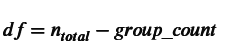

In [19]:
# Размер выборки
n_total = len(df_merged) * (rollout_share / 100) # размер выборки * % трафика для эксперимента
n = n_total / group_count # размер одной группы
degrees_of_freedom = n_total - group_count # учитываем количество групп в расчете степеней свободы
display(n_total, n, degrees_of_freedom)

3289.5

1096.5

3286.5

In [20]:
# Считаем статистики по линеаризованной метрике
std = df_merged['linearized_metric'].std()
mean = df_merged['linearized_metric'].mean() # нужно для расчета лифта

In [21]:
# С помощью функции ppf рассчитываем критические значения (границы) t-распределения, 
# которые отделяют зону допустимых случайных отклонений от зоны статистической значимости
# параметры функции t.ppf(Квантиль, Степени свободы)
# t_alpha: - «граница» для ошибки I рода. t_beta: - «граница» для мощности. 
t_alpha = t.ppf(1 - alpha / 2, degrees_of_freedom)
t_beta = t.ppf(1 - beta, degrees_of_freedom)

Далее, считаем MDE по формуле :

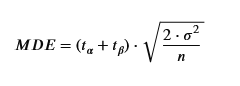

In [22]:
# Расчет MDE
left_factor = (t_alpha + t_beta) ** 2 ## возводим в квадрат, чтобы потом вычесть корень вместе с правой частью
right_factor = 2 * (std ** 2) / n
MDE_lin = (left_factor * right_factor) ** 0.5

In [23]:
# Преобразуем к ratio-метрике
abs_mde = MDE_lin / df_merged[denominator].mean()
rel_mde = ((abs_mde / global_ratio) * 100).round(2)

# Вывод
print(f"Абсолютный MDE метрики-отношения: {abs_mde}")
print(f"Относительный MDE метрики-отношения, в %: {rel_mde}%")

Абсолютный MDE метрики-отношения: 0.027625998395166933
Относительный MDE метрики-отношения, в %: 3.16%


Для выбранного размера трафика = 50% MDE - рассчитан и удовлетворяет требованиям.

**Вывод по дизайну эксперимента:**

- Для оценки конверсии из заказа в успешную поездку C2R (Ratio-метрика) была применена техника линеаризации. Это позволило снизить дисперсию и корректно использовать t-критерий Стьюдента.
- При текущих параметрах (распределение трафика 50% на 3 группы, уровень значимости 5% и мощность 80%) полученные результаты дизайна следующие:

- Абсолютный MDE:  0.027625998395166933 — это минимальное изменение конверсии в процентных пунктах, которое мы сможем статистически значимо зафиксировать.
- Относительный MDE: 3.16% — именно на столько (минимум) должна вырасти текущая конверсия, чтобы эксперимент был признан успешным при данном объеме выборки.

## Оценка корректности проведения теста

Отслеживаем проведение теста на начальном этапе.

#### Проверка сплитования пользователей

Пользователи в эксперименте могли попасть сразу в несколько групп тестирования одновременно. Проверим это.

In [24]:
# Загружаем данные сплита
try:
    split_data = pd.read_csv('datasets/PA_5_10_1_split_data.csv')
    display(f'Файл успешно загружен') 
except:
    display(f'Ошибка при загрузке файла')     

'Файл успешно загружен'

In [25]:
split_data.head()

,user_id,time,group_name
0,43a5b22e-6fed-4c22-9855-82d3304b3031,2024-10-14 00:00:00,treatment_2
1,6640de09-bbb9-4a85-ab91-2b6c032da764,2024-10-14 00:01:53,treatment_1
2,f2666461-054d-4aeb-b9a4-c9a5477da043,2024-10-14 00:05:34,treatment_2
3,0d3faf2d-4da9-47dc-bdba-c29dc3863b5d,2024-10-14 00:05:48,control
4,180e1d77-818f-4c29-87bf-f86b52249359,2024-10-14 00:13:31,treatment_2


In [26]:
split_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4357 entries, 0 to 4356
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4357 non-null   object
 1   time        4357 non-null   object
 2   group_name  4357 non-null   object
dtypes: object(3)
memory usage: 102.2+ KB


In [27]:
# преобразуем столбец в дату
split_data['time'] = pd.to_datetime(split_data['time'])

In [28]:
set_users_A = set(split_data['user_id'].loc[split_data['group_name'] == 'control'])

In [29]:
set_users_B = set(split_data['user_id'].loc[split_data['group_name'] == 'treatment_1'])

In [30]:
set_users_C = set(split_data['user_id'].loc[split_data['group_name'] == 'treatment_2'])

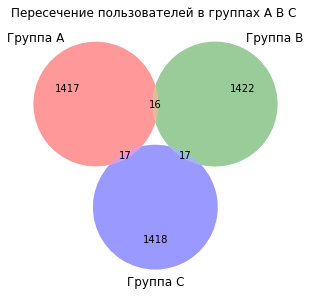

In [31]:
# Строим диаграмму Венна
v = venn3(subsets=[set_users_A, set_users_B, set_users_C], \
          set_labels=('Группа А', 'Группа B', 'Группа C'))
plt.title("Пересечение пользователей в группах А В C ")
plt.show()   

Очистим таблицу split_data от дублирующихся пользователей.

In [32]:
# Считаем кол-во уникальных групп на user_id
flawed_users = split_data.groupby('user_id')['group_name'].nunique().reset_index()

# Фильтруем клиентов у которых больше 1 группы
flawed_users = flawed_users.loc[flawed_users['group_name'] > 1]

# Убираем пользователей, попавших в несколько групп
split_data_correct = split_data.loc[~split_data['user_id'].isin(flawed_users['user_id'])]

display('Данные очищены')

'Данные очищены'

In [33]:
split_data_correct.head()

,user_id,time,group_name
0,43a5b22e-6fed-4c22-9855-82d3304b3031,2024-10-14 00:00:00,treatment_2
1,6640de09-bbb9-4a85-ab91-2b6c032da764,2024-10-14 00:01:53,treatment_1
2,f2666461-054d-4aeb-b9a4-c9a5477da043,2024-10-14 00:05:34,treatment_2
3,0d3faf2d-4da9-47dc-bdba-c29dc3863b5d,2024-10-14 00:05:48,control
4,180e1d77-818f-4c29-87bf-f86b52249359,2024-10-14 00:13:31,treatment_2


In [34]:
split_data_correct.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4257 entries, 0 to 4306
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4257 non-null   object        
 1   time        4257 non-null   datetime64[ns]
 2   group_name  4257 non-null   object        
dtypes: datetime64[ns](1), object(2)
memory usage: 133.0+ KB


#### Подготовка данных к расчету метрик

Подготовим датасеты заказов и событий за период эксперимента. 
Из данных заказов уберем заказы со статусом *'cancelled_by_driver'*.
В получившихся датасетах каждому клиенту добавим признак группы, в которую он попал.

In [35]:
# Преобразование времени
orders['order_time'] = pd.to_datetime(orders['order_time'])
events['time'] = pd.to_datetime(events['time'])

In [36]:
# Указываем переменные начала и конца экспериментального периода
start_date = pd.Timestamp('2024-10-14 00:00:00')
end_date = pd.Timestamp('2024-10-27 23:59:59')

# Фильтруем датасет по датам и статусу заказа
data_exp_orders = orders.loc[
    (orders['order_time'] >= start_date) & 
    (orders['order_time'] <= end_date) &
    (orders['status'] != 'cancelled_by_driver')]

# Фильтруем датасет событий по датам
data_exp_events = events.loc[(events['time'] >= start_date) &   (events['time'] <= end_date)]

In [37]:
# Объединение таблицы с событиями с данными о группах
data_exp_orders =pd.merge(data_exp_orders, split_data_correct[['user_id','group_name']], on='user_id', how='inner' )
# Объединение таблицы с событиями с данными о группах
data_exp_events = pd.merge(data_exp_events, split_data_correct[['user_id','group_name']], on='user_id', how='inner' )

In [38]:
print(data_exp_orders.head(5))
print(data_exp_events.head(5))

   index                               user_id                              order_id          order_time          ride_start_time     ride_finish_time     status  paid_amt payment_type group_name
0     14  00019148-3158-4ebe-aae0-25cd0e1b1b8a  a4e8f585-6963-4de7-9c0d-85631cd0aec3 2024-10-23 02:58:57  2024-10-23 03:05:47.240  2024-10-23 03:41:41  completed      1025         card    control
1     15  00019148-3158-4ebe-aae0-25cd0e1b1b8a  a42ca294-1daf-4abb-8781-16c957cb7336 2024-10-23 07:54:28  2024-10-23 07:59:55.960  2024-10-23 08:24:50  completed       364         card    control
2     16  00019148-3158-4ebe-aae0-25cd0e1b1b8a  a6d71fde-efb8-4087-ba44-1a6c0b164337 2024-10-27 12:03:40  2024-10-27 12:09:47.400  2024-10-27 12:31:30  completed       640         card    control
3    100  001c57aa-e1f1-40bf-9d79-8e064ee03891  736e2057-2e58-4eb6-82ca-12615e7fa533 2024-10-22 08:05:39  2024-10-22 08:12:56.760  2024-10-22 08:36:03  completed       304         card    control
4    182  0031962e-7

#### Мониторинг метрик

##### **Мониторинг ключевой метрики**

Рассчитаем и визуализируем **кумулятивные** значения ключевой метрики **C2R** (конверсия из создания заказа в успешную поездку) для тестовых групп за весь период эксперимента. Это позволит проанализировать динамику метрики на предмет искажений пользовательского поведения и первоначально оценить эффект гипотезы.

Кумулятивную конверсию на каждый день эксперимента отобразим на графике.

In [39]:
# Пустой список для результатов
records = []

# Формируем лист дат для цикла и сортируем его
date_list = data_exp_orders['order_time'].dt.date.unique()
date_list.sort()

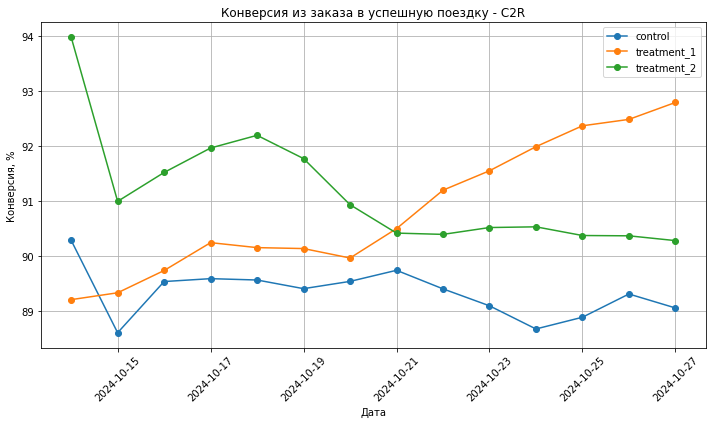

In [40]:
# Конверсия из создания заказа в успешную поездку
for current_date in date_list:
    # Заказы до текущей даты включительно
    orders_to_date = data_exp_orders.loc[data_exp_orders['order_time'].dt.date <= pd.to_datetime(current_date).date()]
    # Фильтрация по статусу
    completed_orders_to_date = orders_to_date.loc[orders_to_date['status'] == 'completed']

    # Общее количество заказов в каждой группе, столбец - total_orders
    total_orders_by_group = orders_to_date.groupby('group_name')['order_id'].nunique().reset_index()
    # Переименование столбца
    total_orders_by_group = total_orders_by_group.rename(columns={'order_id': 'total_orders'})

    # Общее количество завершённых заказов в каждой группе, столбец - completed_orders
    completed_orders_by_group = completed_orders_to_date.groupby('group_name')['order_id'].nunique().reset_index() 
    # Переименование столбца
    completed_orders_by_group = completed_orders_by_group.rename(columns={'order_id': 'completed_orders'})
    
    # Объединение и расчёт конверсии
    df_merged_orders = pd.merge(total_orders_by_group, completed_orders_by_group, on='group_name', how='inner')
    df_merged_orders['conversion'] = df_merged_orders['completed_orders'] * 100/df_merged_orders['total_orders'] 

    df_merged_orders['date'] = current_date
    records.append(df_merged_orders)
    
    # Собираем всё в итоговый датафрейм
    conversion_df = pd.concat(records)
        
# Строим график
plt.figure(figsize=(10, 6))
for group in conversion_df['group_name'].unique():
    group_data = conversion_df.loc[conversion_df['group_name'] == group]
    plt.plot( group_data['date'], group_data['conversion'] , marker='o', label=group)
   
plt.title('Конверсия из заказа в успешную поездку - C2R')
plt.xlabel('Дата')
plt.ylabel('Конверсия, %')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Вывод:** 
- Группа treatment_1 демонстрирует устойчивый рост конверсии после 20 октября;
- Кривая группы control демонстрирует минимальные колебания и остаётся почти неизменной на всём протяжении эксперимента.

##### **Мониторинг барьерной метрики**

Рассчитаеv и визуализируем **кумулятивные значения барьерной метрики** (выручка на пользователя экспериментальных групп) за весь период эксперимента. Это позволит убедиться, что **эксперимент не снизил выручку.**

Отобразим динамику метрики на графике.

Формула выручки на пользователя: сумма выручки за заказы / общее количество поездок пользователей.

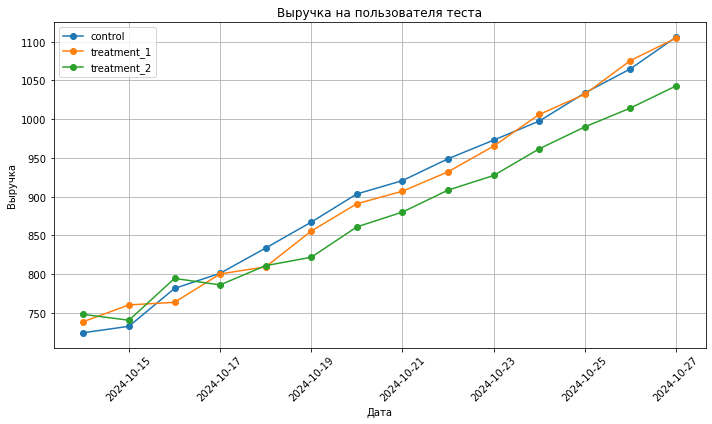

In [41]:
# Пустой список для результатов
records = []

# Формируем лист дат для цикла и сортируем его
date_list = data_exp_orders['order_time'].dt.date.unique()
date_list.sort()

# Выручка на пользователя теста
for current_date in date_list:
    # Выполненные заказы до текущей даты включительно
    completed_orders_to_date = data_exp_orders.loc[data_exp_orders['order_time'].dt.date <= pd.to_datetime(current_date).date()]
        
    # Фильтрация по статусу
    completed_orders_to_date = completed_orders_to_date.loc[completed_orders_to_date['status'] == 'completed']

    # Суммарная выручка по группам
    summa_by_group = completed_orders_to_date.groupby('group_name')['paid_amt'].sum().reset_index()
    # Переименование столбца
    summa_by_group = summa_by_group.rename(columns={'paid_amt': 'revenue_total'})

    # Количество уникальных пользователей, совершивших заказ, по группам
    users_by_group = completed_orders_to_date.groupby('group_name')['user_id'].nunique().reset_index()
    # Переименование столбца
    users_by_group = users_by_group.rename(columns={'user_id': 'users_total'})

    # Объединение и расчёт выручки на пользователя
    df_merged_orders = pd.merge(summa_by_group, users_by_group, on='group_name', how='inner')
    df_merged_orders['revenue_per_user'] = df_merged_orders['revenue_total']/df_merged_orders['users_total']

    df_merged_orders['date'] = current_date
    records.append(df_merged_orders)

    # Собираем в итоговый датафрейм
    revenue_df = pd.concat(records)

# Строим график
plt.figure(figsize=(10, 6))
for group in revenue_df['group_name'].unique():
    group_data = revenue_df.loc[revenue_df['group_name'] == group]
    plt.plot(group_data['date'], group_data['revenue_per_user'], marker='o', label=group)

plt.title('Выручка на пользователя теста')
plt.xlabel('Дата')
plt.ylabel('Выручка')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Вывод:**
- У группы treatment_2 барьерная метрика ухудшается и показывает значения ниже, чем у контрольной группы.
- У группы treatment_1 не наблюдается стагнации метрики, на протяжении эксперимента она остаётся на одном уровне с контрольной.

Следующий шаг эксперимента - довести его до конца. Оценивать результат и принимать решение об успехе или неуспешности эксперимента стоит только в финальной точке, так как подглядывание за p-value может привести к ложным выводам. 

## Анализ результатов теста

### Расчёт ключевой метрики

Построим таблицу для попарного сравнения групп.
Для удобства восприятия часть метрик выведем в нелинеаризованном виде, но саму статистику будем считать с помощью линеаризации. 

In [42]:
# Расчитываем числитель и знаменатель метрики через группировку и лямбду
df_test = data_exp_orders.groupby(['user_id','group_name']).agg(
    total_rides=('order_id', 'nunique'),
    successful_rides=('status', lambda x: x.eq('completed').sum())).reset_index()
      
# Получаем список всех уникальных групп с сортировкой
groups = df_test['group_name'].unique().tolist()

# Создаём словарь для хранения данных по группам
group_data = {}
for group in groups:
    # Выбираем пользователей группы
    group_data[group] = df_test[df_test['group_name'] == group]
    # Создаём список для хранения результатов
    results = []
    # Проводим попарные сравнения всех групп
    for i in range(len(groups)):
        for j in range(i+1, len(groups)):
            group1 = groups[i]
            group2 = groups[j]
            
            # Расчет метрик
            # ratio - рассчитываем глобальное среднее по данным контрольной группы 
            ratio =  df_test.loc[df_test['group_name'] == group1]['successful_rides'].sum()/df_test.loc[df_test['group_name'] == group1]['total_rides'].sum()
            # применяем линеаризацию к группам
            lin_metric1 = df_test.loc[df_test['group_name'] == group1]['successful_rides'] - ratio*df_test.loc[df_test['group_name'] == group1]['total_rides']
            lin_metric2 = df_test.loc[df_test['group_name'] == group2]['successful_rides'] - ratio*df_test.loc[df_test['group_name'] == group2]['total_rides']       
            
            # Статистический тест
            _, p_value = ttest_ind(lin_metric1, lin_metric2)
            
            # Расчет метрик
            mean1 = df_test.loc[df_test['group_name'] == group1]['successful_rides'].sum()/df_test.loc[df_test['group_name'] == group1]['total_rides'].sum()
            #print(mean1)
            mean2 = df_test.loc[df_test['group_name'] == group2]['successful_rides'].sum()/df_test.loc[df_test['group_name'] == group2]['total_rides'].sum()
            #print(mean2)
            #Добавление результатов
            results.append({
               'Group A': group1,
               'Group B': group2,
               'p-value': p_value,
               'Mean A': mean1,
               'Mean B': mean2,
               'Absolute Lift': mean2 - mean1,
               'Relative Lift (%)': 100*(mean2/mean1-1)
               })

# Создаём DataFrame из результатов
results_df = pd.DataFrame(results)

# Выводим результаты
print("Результаты сравнения групп:")
print(results_df)

Результаты сравнения групп:
       Group A      Group B   p-value    Mean A    Mean B  Absolute Lift  Relative Lift (%)
0      control  treatment_1  0.000008  0.890578  0.927901       0.037324           4.190934
1      control  treatment_2  0.177366  0.890578  0.902809       0.012231           1.373404
2  treatment_1  treatment_2  0.002610  0.927901  0.902809      -0.025092          -2.704199


**Вывод:** Ключевая метрика в тестовой группе treatment_1 была статистически значимо выше, чем в группах control и treatment_2.

### Расчёт вспомогательной метрики 1

Рассчитаем и визуализируем **кумулятивные** значения вспомогательной метрики — **конверсии из просмотра формы в создание заказа.**

Формула: количество пользователей, которые создали заказ / количество пользователей, которые открыли экран заказа. 

Работаем с таблицей events, так как именно в ней фиксируются события просмотра экрана и создания заказа. Созданию заказа соответствует событие *order_create*, а открытию экрана заказа — *order_initiate*. 

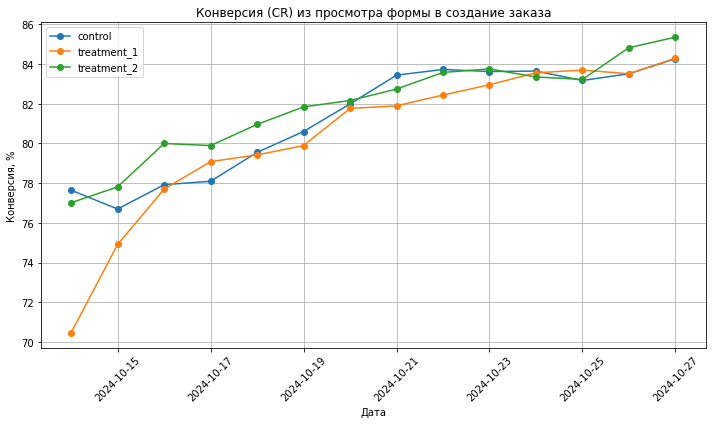

In [43]:
# Пустой список для результатов
records = []

# Формируем лист дат для цикла и сортируем его
date_list = data_exp_events['time'].dt.date.unique()
date_list.sort()

# Конверсия из просмотра формы в создание заказа
for current_date in date_list:
    # События до текущей даты включительно
    events_to_date = data_exp_events.loc[data_exp_events['time'].dt.date <= current_date]
    # Фильтруем order_initiate
    initiated_orders_to_date = events_to_date.loc[events_to_date['event_name'] == 'order_initiate']
    # Фильтруем order_create
    created_orders_to_date = events_to_date.loc[events_to_date['event_name'] == 'order_create']

    # Общее количество пользователей, которые открыли форму заказа, в каждой группе. Столбец с расчётом - users_initiated
    initiated_users_by_group = initiated_orders_to_date.groupby('group_name')['user_id'].nunique().reset_index()
    # Переименовываем столбец
    initiated_users_by_group = initiated_users_by_group.rename(columns={'user_id': 'users_initiated'})
    
    # Количество пользователей, которые создали заказ, в каждой группе. Столбец с расчётом - users_created
    created_users_by_group = created_orders_to_date.groupby('group_name')['user_id'].nunique().reset_index()
    # Переименовываем столбец
    created_users_by_group = created_users_by_group.rename(columns={'user_id': 'users_created'})
    
    # Объединение и расчёт конверсии
    df_merged_events = pd.merge(initiated_users_by_group, created_users_by_group, on='group_name', how='inner')
    df_merged_events['conversion'] = 100 * df_merged_events['users_created']/df_merged_events['users_initiated'] 
    
    df_merged_events['date'] = current_date
    records.append(df_merged_events)
    
# Собираем в итоговый датафрейм
conversion_df = pd.concat(records)

# Строим график
plt.figure(figsize=(10, 6))
for group in conversion_df['group_name'].unique():
    group_data = conversion_df.loc[conversion_df['group_name'] == group]
    plt.plot(group_data['date'], group_data['conversion'], marker='o', label=group)
plt.title('Конверсия (CR) из просмотра формы в создание заказа')
plt.xlabel('Дата')
plt.ylabel('Конверсия, %')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()    

**Вывод:** Вспомогательная метрика CR - конверсии из просмотра формы в создание заказа - не показала серьёзных отклонений в тестовых группах. В метрике есть различия только в первый день, далее метрика выравнивается.

### Расчет вспомогательной метрики 2

Рассчитаем и визуализируем **кумулятивные**значения вспомогательной метрики **«Количество поездок на пользователя экспериментальных групп».** 

Формула: количество поездок, которые завершились успешно / общее количество пользователей, которые совершили успешный заказ.

Успешным поездкам соответствует статус *'completed'*. 

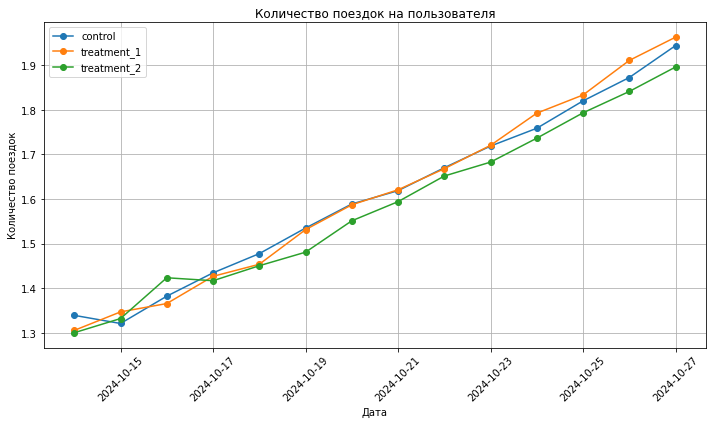

In [44]:
# Пустой список для результатов
records = []

# Формируем лист дат для цикла и сортируем его
date_list = data_exp_orders['order_time'].dt.date.unique()
date_list.sort()

# Конверсия из просмотра формы в создание заказа
for current_date in date_list:
    # Выполненные заказы до текущей даты включительно
    completed_orders_to_date = data_exp_orders.loc[data_exp_orders['order_time'].dt.date <= current_date]
    # Фильтрация по статусу
    completed_orders_to_date = completed_orders_to_date.loc[completed_orders_to_date['status'] == 'completed']
   
    # Количество заказов (поездок) всего. Столбец с расчётом — orders_total
    orders_by_group = completed_orders_to_date.groupby('group_name')['order_id'].nunique().reset_index()
    # Переименовать столбец
    orders_by_group = orders_by_group.rename(columns={'order_id': 'orders_total'})

    # Количество уникальных пользователей, совершивших заказ, по группам. Столбец с расчётом — users_total
    users_by_group = completed_orders_to_date.groupby('group_name')['user_id'].nunique().reset_index()
    # Переименовать столбец
    users_by_group = users_by_group.rename(columns={'user_id': 'users_total'})

    # Объединение и расчёт количества поездок на пользователя
    df_merged_orders = pd.merge(orders_by_group, users_by_group, how='outer', on='group_name')

    df_merged_orders['trips_per_user_to_date'] =  df_merged_orders['orders_total']/df_merged_orders['users_total']

    df_merged_orders['date'] = current_date
    records.append(df_merged_orders)

# Собираем в итоговый датафрейм
trips_number_df = pd.concat(records)

# Строим график
plt.figure(figsize=(10, 6))

for group in trips_number_df['group_name'].unique():
    group_data = trips_number_df[trips_number_df['group_name'] == group]
    plt.plot(group_data['date'], group_data['trips_per_user_to_date'], marker='o', label=group)

plt.title('Количество поездок на пользователя')
plt.xlabel('Дата')
plt.ylabel('Количество поездок')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Вывод:** Изменения в поведении метрики количество поездок на пользователя отсутствуют. 

## Аналитический вывод по итогам теста

- В рамках эксперимента была протестирована **новая математическая модель**, которая более точно прогнозирует время ожидания такси заказчиком. Ключевая метрика - конверсия из создания заказа в успешную поездку.

- В качестве статистического критерия применён t-тест с линеаризацией, так как ключевая метрика - метрика отношения. 

- Группы сравнения:
    - Control — Treatment 1. Статистически значимый рост метрики: среднее значение выросло с 0.87 до 0.90 (+0.33 — в абсолютном выражении, +3.88% — в относительном выражении), p-value = 0.000182
    - Control — Treatment 2. p-value = 0.5165. Статистически ключевая метрика лучше в контрольной группе.
    - Treatment 1 — Treatment 2. Различия между двумя вариантами математической модели статистически значимы: p-value = 0.0033, ключевая метрика лучше в Treatment 1 группе.

**Вывод:** Эксперимент можно считать **успешным**. Фича увеличивает вероятность того, что заказ пользователя завершится успешной поездкой. Рекомендовано внедрение фичи для всех пользователей в варианте **treatment_1**.